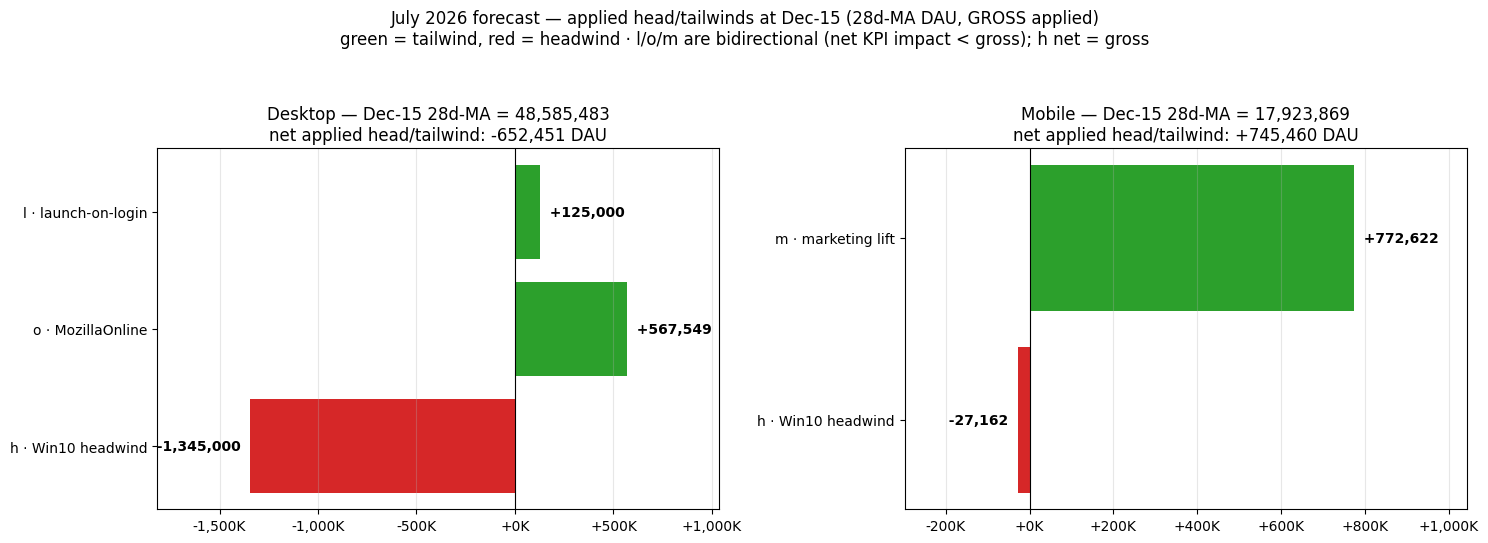

saved data-official/2026-07/plots/headwind_tailwind_breakdown.png
Desktop: l +125,000 | o +567,549 | h -1,345,000  => net applied -652,451
Mobile : m +772,622 | h -27,162  => net applied +745,460


In [1]:
# [headwind-tailwind-breakdown]
# Applied head/tailwinds at the Dec-15 2026 measurement (28d-MA DAU), read straight from the
# curve/spec files so this stays a single source of truth. GROSS = the modeled lift/headwind actually
# applied. The l/o/m overlays are BIDIRECTIONAL (model trained on data with the lift removed, then the
# lift added back), so their *net* change to the KPI vs a no-overlay run is somewhat smaller than the
# gross bar; the h headwind is a pure display subtraction, so its net == gross.
import os, json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
os.chdir(__import__("subprocess").run(["git","rev-parse","--show-toplevel"],
         capture_output=True, text=True).stdout.strip())

MEAS = pd.Timestamp("2026-12-15")
hw = json.load(open("data-official/2026-07/adjustments/headwind.json"))


def ma_at(path, col):
    df = pd.read_parquet(path); df.index = pd.to_datetime(df.index)
    return float(df[col].rolling(28, min_periods=28).mean().loc[MEAS])


l = ma_at("data-official/2026-07/launch_on_login/lol_tailwind.2026-06-29.parquet", "lol_lift_daily")
o = ma_at("data-official/2026-07/mozillaonline/mozillaonline_migration_model.official.2026-06-29.parquet", "migration_dau_daily")
m = ma_at("data-official/2026-07/marketing/marketing_lift_model.total.2026-06-29.parquet", "marketing_lift_daily")
hd, hm = float(hw["desktop_dau"]), float(hw["mobile_dau"])

DESK = [("l · launch-on-login", l), ("o · MozillaOnline", o), ("h · Win10 headwind", hd)]
MOB = [("m · marketing lift", m), ("h · Win10 headwind", hm)]
DESK_FINAL, MOB_FINAL = 48_585_483, 17_923_869
GREEN, RED = "#2ca02c", "#d62728"

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, title, rows, final, net in [
    (axes[0], "Desktop", DESK, DESK_FINAL, sum(v for _, v in DESK)),
    (axes[1], "Mobile", MOB, MOB_FINAL, sum(v for _, v in MOB)),
]:
    labels = [r[0] for r in rows][::-1]
    vals = [r[1] for r in rows][::-1]
    colors = [GREEN if v >= 0 else RED for v in vals]
    ax.barh(labels, vals, color=colors)
    ax.axvline(0, color="black", lw=0.8)
    for i, v in enumerate(vals):
        ax.text(v, i, f"  {v:+,.0f}  ", va="center",
                ha="left" if v >= 0 else "right", fontsize=10, fontweight="bold")
    ax.set_title(f"{title} — Dec-15 28d-MA = {final:,}\n"
                 f"net applied head/tailwind: {net:+,.0f} DAU", fontsize=12)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:+,.0f}K"))
    ax.grid(True, axis="x", alpha=0.3)
    pad = max(abs(v) for v in vals) * 0.35
    ax.set_xlim(min(vals) - pad, max(vals) + pad)

fig.suptitle("July 2026 forecast — applied head/tailwinds at Dec-15 (28d-MA DAU, GROSS applied)\n"
             "green = tailwind, red = headwind · l/o/m are bidirectional (net KPI impact < gross); h net = gross",
             fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.93])
out = "data-official/2026-07/plots/headwind_tailwind_breakdown.png"
os.makedirs(os.path.dirname(out), exist_ok=True)
plt.savefig(out, dpi=140, bbox_inches="tight")
plt.show()
print(f"saved {out}")
print(f"Desktop: l {l:+,.0f} | o {o:+,.0f} | h {hd:+,.0f}  => net applied {sum(v for _,v in DESK):+,.0f}")
print(f"Mobile : m {m:+,.0f} | h {hm:+,.0f}  => net applied {sum(v for _,v in MOB):+,.0f}")
